In [1]:
import adc
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt

font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 11}

matplotlib.rc('font', **font)

## ADC Evaluierung

Einlesen der Messdaten

In [2]:
df_u_edge_meas = pd.read_csv('data/adc_u_edge.csv')

flash = adc.ADC('Flash ADC', df_u_edge_meas['flash'])
sar = adc.ADC('SAR ADC', df_u_edge_meas['sar'])
ds = adc.ADC('Dual Slope ADC', df_u_edge_meas['dual_slope'])

### Kennlinie

In [3]:
for converter in [flash, sar, ds]:
	converter.save_curve(f'latex/images/{converter.name.lower().replace(" ", "_")}_curve.png')
	# converter.plot_curve()

### Tabellen

In [4]:
for converter in [flash, sar, ds]:
	converter.to_latex()
	converter.err_to_latex()

## DAC Kennlinie für SAR-ADC

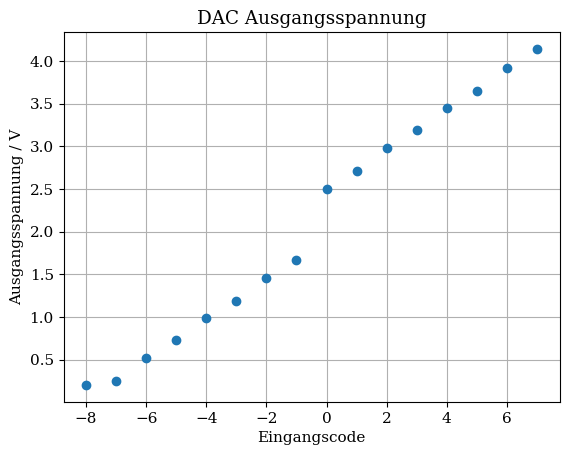

In [5]:
dac_values = pd.read_csv('data/dac.csv')
plt.plot(dac_values['code'], dac_values['u_out'], marker='o', linestyle='')
plt.title('DAC Ausgangsspannung')
plt.xlabel('Eingangscode')
plt.ylabel('Ausgangsspannung / V')
plt.grid(True)
plt.show()